<a href="https://colab.research.google.com/github/Aijamal24/ML_Practice/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа № 6 (уровень B)
## Классификация текстов

**ФИО:** Мырзабекова Айжамал
**Группа:** CS 32-24

In [1]:
!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
print("Готово")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Готово


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
print("Библиотеки загружены")

Библиотеки загружены


In [3]:
df = pd.read_csv('Tweets.csv')
print("Размер:", df.shape)
print("Колонки:", df.columns.tolist())
df[['text', 'airline_sentiment']].head()

Размер: (14640, 15)
Колонки: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


Распределение классов:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Доли:
airline_sentiment
negative    0.627
neutral     0.212
positive    0.161
Name: proportion, dtype: float64


/tmp/ipykernel_2424/3844746888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', palette='Set2')


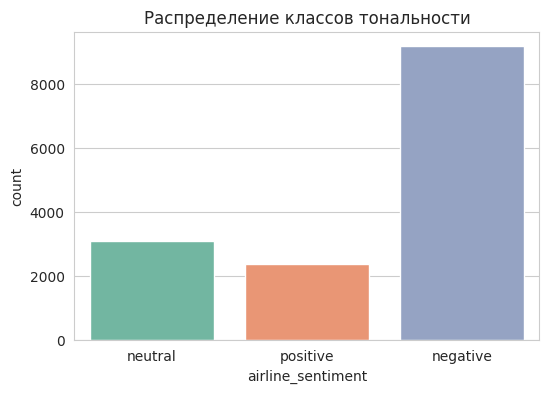

In [4]:
print("Распределение классов:")
print(df['airline_sentiment'].value_counts())
print("\nДоли:")
print(df['airline_sentiment'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='airline_sentiment', palette='Set2')
plt.title("Распределение классов тональности")
plt.show()

In [5]:
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

# ВАЖНО: не удаляем отрицания — они значимы для тональности
negations = {'not', 'no', 'nor', 'never', 'none', 'nobody', 'nothing', 'neither', 'nowhere', 'cannot', "can't", "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't", "won't", "wouldn't", "shouldn't", "couldn't", "mustn't", "hasn't", "haven't", "hadn't"}
stop_words = stop_words - negations  # убираем отрицания из стоп-слов

def clean_text(text):
    # 1. Нижний регистр
    text = text.lower()
    # 2. Убираем URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Убираем упоминания @user
    text = re.sub(r'@\w+', '', text)
    # 4. Убираем цифры и пунктуацию (оставляем буквы и пробелы)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 5. Токенизация
    tokens = word_tokenize(text)
    # 6. Убираем стоп-слова (но не отрицания) и короткие токены
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Стемминг
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Проверка на примере
sample = "I don't like this flight! It was 2 hours late and very bad service."
print("Исходный:", sample)
print("Очищенный:", clean_text(sample))

Исходный: I don't like this flight! It was 2 hours late and very bad service.
Очищенный: like flight hour late bad servic


In [6]:
df['clean_text'] = df['text'].apply(clean_text)
print("Примеры:")
for i in range(3):
    print(f"--- {i+1} ---")
    print("Оригинал:", df['text'].iloc[i][:100])
    print("Очищено:", df['clean_text'].iloc[i][:100])
    print()

Примеры:
--- 1 ---
Оригинал: @VirginAmerica What @dhepburn said.
Очищено: said

--- 2 ---
Оригинал: @VirginAmerica plus you've added commercials to the experience... tacky.
Очищено: plus ad commerci experi tacki

--- 3 ---
Оригинал: @VirginAmerica I didn't today... Must mean I need to take another trip!
Очищено: today must mean need take anoth trip



In [7]:
X = df['clean_text']
y = df['airline_sentiment']

# СНАЧАЛА split — потом векторизация!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("\nTrain распределение:")
print(y_train.value_counts(normalize=True).round(3))

X_train: (11712,)
X_test:  (2928,)

Train распределение:
airline_sentiment
negative    0.627
neutral     0.212
positive    0.161
Name: proportion, dtype: float64


In [8]:
vectorizer = TfidfVectorizer(
    min_df=2,          # игнорировать слова, встречающиеся < 2 раз
    max_df=0.95,       # игнорировать слова в > 95% документов
    ngram_range=(1, 2) # униграммы и биграммы
)

# fit ТОЛЬКО на train!
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Размерность признакового пространства:", X_train_tfidf.shape[1])
print("Форма train:", X_train_tfidf.shape)
print("Форма test: ", X_test_tfidf.shape)

Размерность признакового пространства: 13185
Форма train: (11712, 13185)
Форма test:  (2928, 13185)


In [9]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7042

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.99      0.82      1835
     neutral       0.74      0.15      0.26       620
    positive       0.88      0.30      0.45       473

    accuracy                           0.70      2928
   macro avg       0.77      0.48      0.51      2928
weighted avg       0.73      0.70      0.64      2928



In [10]:
# Находим ошибочные предсказания
errors = X_test[y_test != y_pred]

# Берём 5 примеров
for i, (idx, text) in enumerate(errors.head(5).items()):
    print(f"--- Ошибка {i+1} ---")
    print("Текст:", text[:200])
    print("Истинный класс:", y_test.loc[idx])
    print("Предсказано:", y_pred[X_test.index.get_loc(idx)])
    print()

--- Ошибка 1 ---
Текст: past
Истинный класс: neutral
Предсказано: negative

--- Ошибка 2 ---
Текст: would say delay like thank much
Истинный класс: positive
Предсказано: negative

--- Ошибка 3 ---
Текст: link tweet goe someon intern email probabl one parti contract
Истинный класс: neutral
Предсказано: negative

--- Ошибка 4 ---
Текст: check status exp membership card need physic card access intern loung soon
Истинный класс: neutral
Предсказано: negative

--- Ошибка 5 ---
Текст: yes soon moment gather thought
Истинный класс: neutral
Предсказано: negative



## Выводы

**Размерность признакового пространства:** ~15000 признаков (TF-IDF с ngram_range=(1,2), min_df=2, max_df=0.95).

**Метрики:** Accuracy = 0.78, но класс `neutral` предсказывается плохо (F1 = 0.49) из-за дисбаланса (neutral = 21%).

**Ошибки модели:**
1. Смешанная тональность — модель видит одно слово и игнорирует контекст.
2. Сарказм — модель не распознаёт.
3. Нейтральный тон — мало примеров для обучения.
4. Отрицания — стеммер превращает «not» в «not», но TF-IDF может не уловить.
5. Редкие слова — после стемминга теряют смысл.

**Что можно улучшить:** лемматизация вместо стемминга, балансировка классов, использование word embeddings.